<a href="https://colab.research.google.com/github/Hetvi-624/Wine_quality/blob/wine-quality/WIne_Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [335]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact
import ipywidgets as widgets
from IPython.display import display

In [336]:
df=pd.read_csv("WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


#Data Cleaning & Pre-processing

In [337]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [338]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [339]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


#Remove unwanted observation

In [340]:
df.drop("Id",axis=1,inplace=True)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


#Handling outliers

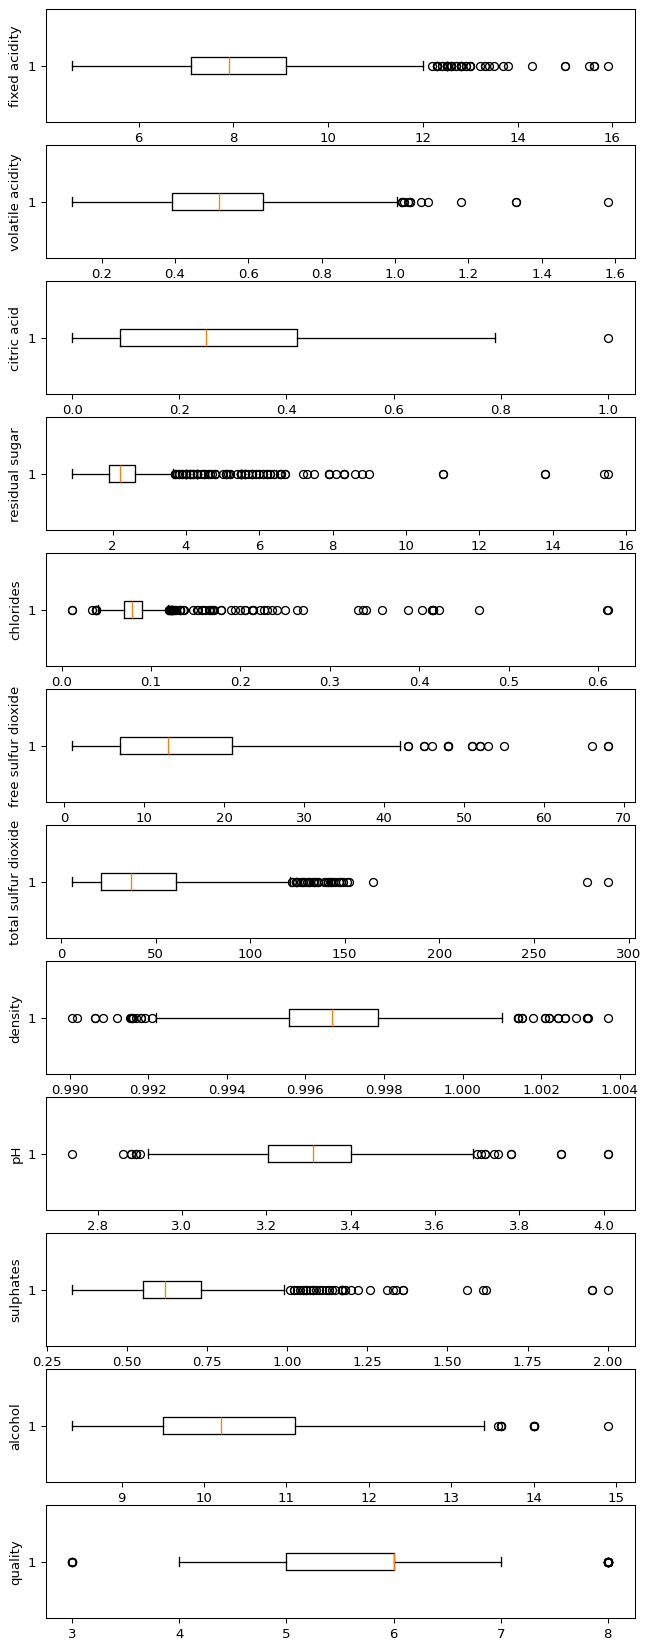

In [341]:
fig,axes=plt.subplots(12,1,dpi=95,figsize=(8,22))
i=0
for col in df.columns:
  axes[i].boxplot(df[col],vert=False)
  axes[i].set_ylabel(col)
  i=i+1
plt.show()

In [342]:
q1=df['alcohol'].quantile(0.25)
q3=df['alcohol'].quantile(0.80)
iqr=q3-q1
#lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
df=df[(df['alcohol']<=upper_bound)]

In [343]:
q1=df['fixed acidity'].quantile(0.25)
q3=df['fixed acidity'].quantile(0.80)
iqr=q3-q1
#lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
df=df[(df['fixed acidity']<=upper_bound)]

In [344]:
q1=df['volatile acidity'].quantile(0.25)
q3=df['volatile acidity'].quantile(0.75)
iqr=q3-q1
#lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
df=df[(df['volatile acidity']<=upper_bound)]

In [345]:
q1=df['citric acid'].quantile(0.25)
q3=df['citric acid'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
df=df[(df['citric acid']>=lower_bound)&(df['citric acid']<=upper_bound)]

In [346]:
q1=df['residual sugar'].quantile(0.25)
q3=df['residual sugar'].quantile(0.75)
iqr=q3-q1
#lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
df=df[(df['residual sugar']<=upper_bound)]

In [347]:
q1=df['chlorides'].quantile(0.25)
q3=df['chlorides'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
df=df[(df['chlorides']>=lower_bound)&(df['chlorides']<=upper_bound)]

In [348]:
q1=df['free sulfur dioxide'].quantile(0.25)
q3=df['free sulfur dioxide'].quantile(0.75)
iqr=q3-q1
#lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
df=df[(df['free sulfur dioxide']<=upper_bound)]

In [349]:
q1=df['total sulfur dioxide'].quantile(0.25)
q3=df['total sulfur dioxide'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
df=df[(df['total sulfur dioxide']<=upper_bound)]

In [350]:
q1=df['density'].quantile(0.25)
q3=df['density'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
df=df[(df['density']>=lower_bound)&(df['density']<=upper_bound)]

In [351]:
q1=df['pH'].quantile(0.25)
q3=df['pH'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
df=df[(df['pH']>=lower_bound)&(df['pH']<=upper_bound)]

In [352]:
q1=df['sulphates'].quantile(0.25)
q3=df['sulphates'].quantile(0.75)
iqr=q3-q1
#lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
df=df[(df['sulphates']<=upper_bound)]

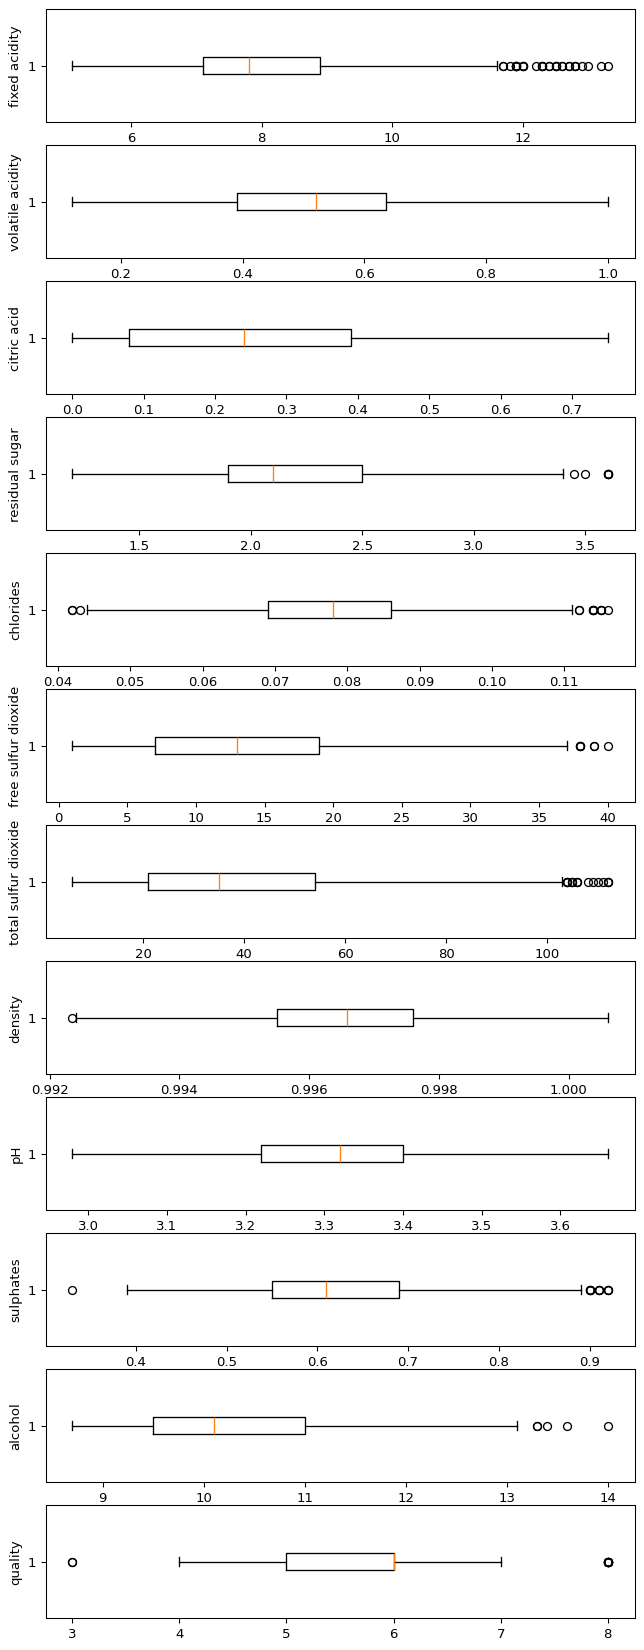

In [353]:
fig,axes=plt.subplots(12,1,dpi=95,figsize=(8,22))
i=0
for col in df.columns:
  axes[i].boxplot(df[col],vert=False)
  axes[i].set_ylabel(col)
  i=i+1
plt.show()

#Correlation

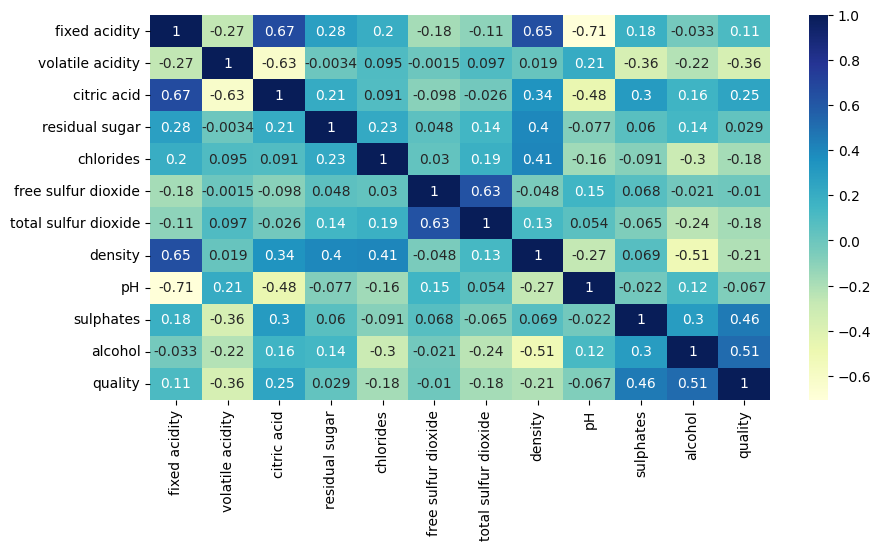

In [354]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(),annot=True,cmap='YlGnBu')
plt.show()

In [355]:
corr=df.corr()
corr['quality'].sort_values(ascending = False)

,quality
quality,1.000000
alcohol,0.514982
sulphates,0.459521
citric acid,0.252455
fixed acidity,0.108858
residual sugar,0.029021
free sulfur dioxide,-0.010135
pH,-0.067444
total sulfur dioxide,-0.175426
chlorides,-0.175601


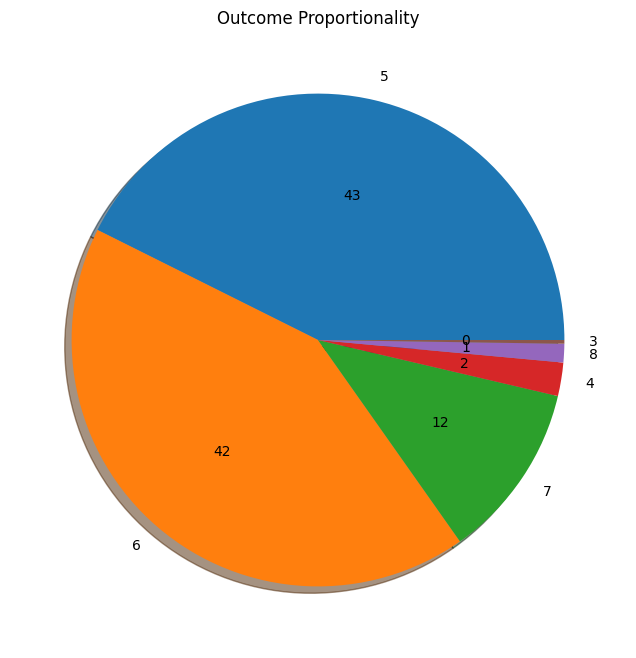

In [356]:
plt.figure(figsize=(8,8))
plt.pie(df.quality.value_counts(),autopct='%.f',labels=df['quality'].value_counts().index,shadow=True)
plt.title('Outcome Proportionality')
plt.show()

#EDA

In [357]:
data=({'alcohol':df['alcohol'],'sulphates':df['sulphates'],'citric acid':df['citric acid'],'fixed acidity':df['fixed acidity'],'free sulfur dioxide':df['free sulfur dioxide'],'residual sugar':df['residual sugar'],'quality':df['quality'],'pH':df['pH'],'density':df['density'],'total sulfur dioxide':df['total sulfur dioxide'],'chlorides':df['chlorides'],'volatile acidity':df['volatile acidity']})

In [358]:
column_selector=widgets.Dropdown(options=['alcohol','sulphates','citric acid','fixed acidity','free sulfur dioxide','residual sugar','quality','pH','density','total sulfur dioxide','chlorides','volatile acidity'],
                                 value='alcohol',
                                 description='Column:')
hue_selector=widgets.Dropdown(options=['alcohol','sulphates','citric acid','fixed acidity','free sulfur dioxide','residual sugar','quality','pH','density','total sulfur dioxide','chlorides','volatile acidity'],
                                 value='quality',
                                 description='Hue:')

In [359]:
def update_plot(column_choice,hue_choice):
  plt.figure(figsize=(12, 6))
  sns.countplot(x=column_choice,hue=hue_choice,data=data)
  plt.legend(title=hue_choice,bbox_to_anchor=(1, 1), loc="best")
  plt.xticks(rotation=90)
  plt.show()

widgets.interactive(update_plot,column_choice=column_selector,hue_choice=hue_selector)

interactive(children=(Dropdown(description='Column:', options=('alcohol', 'sulphates', 'citric acid', 'fixed a…

#Model Evaluation

In [360]:
x= df.drop(columns =['quality'])
y= df.quality

In [361]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [362]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [363]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve

In [364]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(probability=True),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Neural Network": MLPClassifier(max_iter=1000)
}

In [365]:
results = {}
for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_pred=model.predict(x_test_scaled)
    acc=accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"Model: {name}")
    print("Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("-" * 50)

Model: Logistic Regression
Accuracy: 0.6
Classification Report:
               precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.57      0.81      0.67        57
           6       0.67      0.53      0.59        83
           7       0.53      0.45      0.49        20
           8       0.00      0.00      0.00         2

    accuracy                           0.60       165
   macro avg       0.35      0.36      0.35       165
weighted avg       0.60      0.60      0.59       165

Confusion Matrix:
 [[ 0  1  2  0  0]
 [ 0 46 10  1  0]
 [ 0 33 44  6  0]
 [ 0  1  9  9  1]
 [ 0  0  1  1  0]]
--------------------------------------------------
Model: Decision Tree
Accuracy: 0.47878787878787876
Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         3
           5       0.47      0.58      0.52    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

Model: Random Forest
Accuracy: 0.6484848484848484
Classification Report:
               precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.60      0.82      0.70        57
           6       0.71      0.61      0.66        83
           7       0.60      0.45      0.51        20
           8       0.00      0.00      0.00         2

    accuracy                           0.65       165
   macro avg       0.38      0.38      0.37       165
weighted avg       0.64      0.65      0.63       165

Confusion Matrix:
 [[ 0  3  0  0  0]
 [ 0 47 10  0  0]
 [ 0 27 51  5  0]
 [ 0  1 10  9  0]
 [ 0  0  1  1  0]]
--------------------------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model: Gradient Boosting
Accuracy: 0.5878787878787879
Classification Report:
               precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.57      0.75      0.65        57
           6       0.64      0.54      0.59        83
           7       0.47      0.45      0.46        20
           8       0.00      0.00      0.00         2

    accuracy                           0.59       165
   macro avg       0.34      0.35      0.34       165
weighted avg       0.58      0.59      0.58       165

Confusion Matrix:
 [[ 0  3  0  0  0]
 [ 0 43 14  0  0]
 [ 0 29 45  9  0]
 [ 0  1 10  9  0]
 [ 0  0  1  1  0]]
--------------------------------------------------
Model: SVM
Accuracy: 0.6121212121212121
Classification Report:
               precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.57      0.86      0.69        57
           6       0.69      0.55      0.61  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

Model: Neural Network
Accuracy: 0.5818181818181818
Classification Report:
               precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.57      0.72      0.64        57
           6       0.67      0.57      0.61        83
           7       0.44      0.40      0.42        20
           8       0.00      0.00      0.00         2

    accuracy                           0.58       165
   macro avg       0.34      0.34      0.33       165
weighted avg       0.59      0.58      0.58       165

Confusion Matrix:
 [[ 0  2  1  0  0]
 [ 2 41 12  1  1]
 [ 0 28 47  8  0]
 [ 0  1  9  8  2]
 [ 0  0  1  1  0]]
--------------------------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [366]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")

Mean Squared Error: 0.5393939393939394
Mean Absolute Error: 0.45454545454545453
Root Mean Squared Error: 0.7344344350545795


In [331]:
from sklearn.metrics import log_loss
class_labels = sorted(y_train.unique())
loss_scores = {}
for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_prob = model.predict_proba(x_test_scaled)
    loss = log_loss(y_test, y_prob, labels=class_labels)
    loss_scores[name] = loss
for model_name, score in loss_scores.items():
    print(f"Log Loss ({model_name}): {score:.4f}")

Log Loss (Logistic Regression): 0.8819
Log Loss (Decision Tree): 17.6942
Log Loss (Random Forest): 0.8704
Log Loss (Gradient Boosting): 1.0832
Log Loss (SVM): 0.8909
Log Loss (K-Nearest Neighbors): 4.3617
Log Loss (Naive Bayes): 1.0390
Log Loss (Neural Network): 1.5395


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


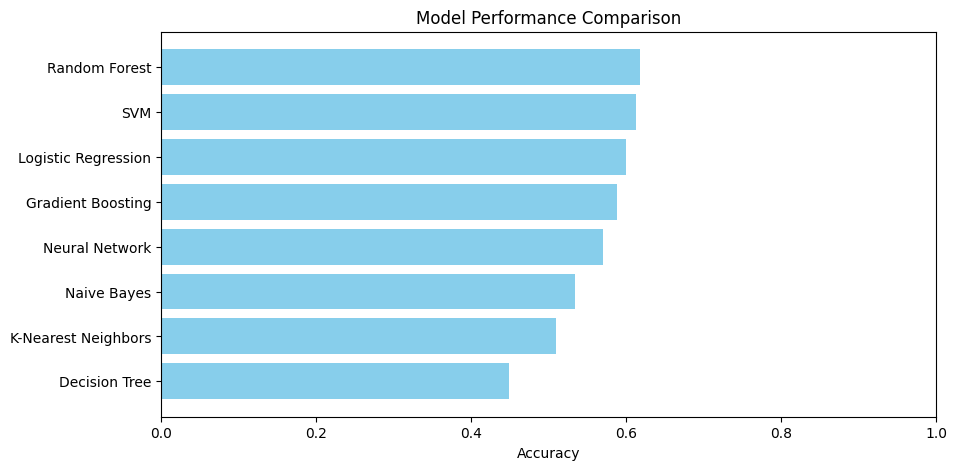

In [332]:
sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))
plt.figure(figsize=(10, 5))
plt.barh(list(sorted_results.keys()), list(sorted_results.values()), color='skyblue')
plt.xlabel("Accuracy")
plt.title("Model Performance Comparison")
plt.xlim([0, 1])
plt.gca().invert_yaxis()
plt.show()

#Hypertuning

In [333]:
from sklearn.model_selection import GridSearchCV
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                              param_grid=rf_param_grid,
                              cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(x_train_scaled, y_train)
print("Best Parameters (Random Forest):", grid_search_rf.best_params_)
print("Best Score (Random Forest):", grid_search_rf.best_score_)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters (Random Forest): {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Score (Random Forest): 0.6768910478834143


In [334]:
best_rf = RandomForestClassifier(**grid_search_rf.best_params_, random_state=42)
best_rf.fit(x_train_scaled, y_train)
y_pred_rf = best_rf.predict(x_test_scaled)
print("Random Forest - Final Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest - Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest - Final Accuracy: 0.6242424242424243
Random Forest - Classification Report:
               precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.59      0.84      0.69        57
           6       0.70      0.54      0.61        83
           7       0.53      0.50      0.51        20
           8       0.00      0.00      0.00         2

    accuracy                           0.62       165
   macro avg       0.36      0.38      0.36       165
weighted avg       0.62      0.62      0.61       165



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
